✅ [7주차 실습] 날씨 데이터 분석 파이프라인 및 엑셀 저장 완성하기
- 데이터 생성 → 전처리 → 분석 → 시각화 -> 파일로 저장
- numpy를 이용해 가상의 시계열 날씨 데이터를 생성
- 시계열 데이터 분석 관련 주요 함수
  - **df.to_excel()**:
    - 여러 개의 분석 결과를 하나의 엑셀 파일(.xlsx) 안에 시트별로 나누어 저장
    - **pd.ExcelWriter()** 를 사용
  - **df.to_csv(encoding='utf-8-sig')** :
    - 전처리가 끝난 "깨끗한" 내부 데이터를 다시 csv 파일로 저장
  - **pd.read_csv(encoding='cp949')** :
    -  외부에서 데이터를 가져오는 것()     
  - **zip()** :
    - 여러 개의 리스트(또는 반복 가능한 객체)를 같은 순서 인덱스끼리 짝을 지어 묶어주는 내장 함수
    - 보통 여러 데이터를 동시에 for문으로 처리할 때 가장 많이 사용     
  - **pd.to_datetime()** :
    - 문자열 "2023-01-01"을 '연/월/일/시/분/초' 날짜 객체 타입으로 변경
    - **df.set_index()** :
      - 데이터프레임의 일반 컬럼을 '인덱스'로 설정
    - 이 두 과정(날짜 데이터변환-> 날짜 기준 인덱스 설정)을 통해 판다스가 날짜를 이해하는 시계열 데이터가 완성    
  - **df[컬럼].interpolate()** :
    - 결측치가 발생했을 때, 앞의 데이터와 뒤의 데이터를 선으로 이어서 그 선 위에 있는 값을 결측치로 논리적으로 채우는 방식
    - 기온, 주가, 센서 데이터처럼 앞뒤 값이 연속성을 가질 때 사용.
    - fillna()로 특정 숫자를 채울 때보다 데이터의 추세를 훨씬 잘 보존
  - **df.rolling()**:
    - '움직이는 창'을 설정해 그 안의 값들을 계산하는 슬라이딩 윈도우 기능
    - 데이터의 급격한 변동을 줄이고 전체적인 추세를 파악.    
  - **Min-Max Scaling**:
    - 서로 다른 범위를 가진 수치 데이터를 0과 1 사이의 일정한 범위로 변환
    - 최소값은 0, 최대값은 1이 되도록 선형적으로 변환.
  - **df.map()** :
    - 시리즈나 인덱스의 각 요소를 하나씩 꺼내어 특정 규칙(함수 또는 딕셔너리)에 통과시킨 뒤, 그 결과값으로 치환하는 기능.   
  - **df.index.month**:
    - 시계열 인덱스에서 'Month' 정보만 뽑아내는 기능.
  - **sns.histplot()**:
    - 데이터가 특정 구간에 얼마나 많이 쌓여 있는지(빈도)를 보여줌
    - **kde=True** 옵션을 넣으면 부드러운 곡선을 그려주어 전체적인 분포의 형태를 쉽게 파악.
  - **sns.heatmap()**:
    - 수치로 가득 찬 표를 색상으로 변환
  - 데이터프레임 결합
    - pd.concat(axis= , join= )
    - df1.merge(df2, on= , how= )
    - df.pivot_table(index =, column = , values= ).sum()

In [ ]:
# 데이터 프레임 결합
import pandas as pd
import numpy as np

# 1. 시계열 데이터프레임 준비 : A지점에서 1월 1일부터 3일간 수집한 기온
df_a = pd.DataFrame({
    'date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03']),
    'temp': [10, 12, 13],
    'location':['A', 'A', 'A']
})
print(df_a)
# 2. 시계열 데이터프레임 준비 : B지점에서 1월 2일부터 4일간 수집한 기온 (날짜가 A와 일부 겹침)
df_b = pd.DataFrame({
    'date': pd.to_datetime(['2023-01-02', '2023-01-03', '2023-01-04']),
    'temp' : [15, 16, 14],
    'location': ['B', "B", "B"]})
print("\n", df_b)

# 3. 물리적으로 모든 지역에서 수집한 기온 통합
df = pd.concat([df_a, df_b], axis = 0, join="outer")
print("\n", df)

# df = pd.concat([df_a, df_b], axis = 0, join="inner")

# 4. 'date'컬럼을 기준으로 "겹치는 날짜"에 대한 정보을 포함하는 테이블
df_merge = df_a.merge(df_b, on = "date", how = "inner", suffixes=("_A", "_B"))
print("\n", df_merge)

# 5. df의 데이터를 사용하여 날짜별/지점별/ 기온/ 표 만들기 : pitvot_table()
df_summary = df.pivot_table(index= 'date', columns = "location", values='temp').sum()
print("\n", df_summary)

        date  temp location
0 2023-01-01    10        A
1 2023-01-02    12        A
2 2023-01-03    13        A

         date  temp location
0 2023-01-02    15        B
1 2023-01-03    16        B
2 2023-01-04    14        B

         date  temp location
0 2023-01-01    10        A
1 2023-01-02    12        A
2 2023-01-03    13        A
0 2023-01-02    15        B
1 2023-01-03    16        B
2 2023-01-04    14        B

         date  temp_A location_A  temp_B location_B
0 2023-01-02      12          A      15          B
1 2023-01-03      13          A      16          B

 location
A    35.0
B    45.0
dtype: float64


In [ ]:
# df.to_csv() & pd.read_csv(), df.to_excel()
import pandas as pd

# 1. 데이터 생성
data = { '도시': ['서울', '부산', '제주'],
        '평균기온': [15.2, 18.5, 20.1]}
df = pd.DataFrame(data)
print("\n", df)

# 2. df-> csv파일 저장 (to_csv())
df.to_csv("sample_data.csv", index = False, encoding = "utf-8-sig" )

# 3. csv -> df 형태로 다시 읽어 오기 (read_csv())
loaded_df =  pd.read_csv("sample_data.csv", encoding = "utf-8") # CP949 차이점
print("\n", loaded_df)

# 4. 엑셀 파일로 저장하기 (df.to_excel())
with pd.ExcelWriter("final_report.xlsx") as f:
  # 각 테이블을 서로 다른 시트 이름으로 저장
  loaded_df.to_excel(f, sheet_name = "날씨 데이터", index = False)
  df.to_excel(f, sheet_name = "전체 데이터", index = False)
  loaded_df.to_excel(f, sheet_name= "데이터분석 결과", index = False)



    도시  평균기온
0  서울  15.2
1  부산  18.5
2  제주  20.1

    도시  평균기온
0  서울  15.2
1  부산  18.5
2  제주  20.1


In [1]:
# zip()
names = ['서울', '부산', '제주']
temps = [15.5, 18.2, 20.1]
# zip으로 묶기 -> 리스트의 동일 인덱스에 있는 것끼리 묶어서 하나의 튜플로 반환
zipped = zip(names, temps)
# print(list(zipped))

# 용도 : 지역과 기온을 동시에 하나씩 꺼내서 출
for name, temp  in zipped:
  print(f"({name},{temp})")


(서울,15.5)
(부산,18.2)
(제주,20.1)


In [2]:
# pd.to_datetime(), df.set_index()
import pandas as pd
# 1. 시계열 데이터 생성
df = pd.DataFrame({'date': ['2025-01-01', '2025-01-02', '2025-01-03'],
                   'temp':[10, 11, 12]})
print("\n", df)
print("\n", df['date'].dtype) # pandas  문자열 자료형 : object
# 2. object => datetime64 (날짜객체타입)
df['date_time']= pd.to_datetime(df["date"])
print("\n",df)
print("\n", df['date_time'].dtype)
# 3.date_time을 데이터프레임의 새 인덱스로 설정 (set_index())
df.set_index('date_time', inplace = True)
print("\n", df)
# 4. 월 정보을 추출
print(df.index.day)


          date  temp
0  2025-01-01    10
1  2025-01-02    11
2  2025-01-03    12

 object

          date  temp  date_time
0  2025-01-01    10 2025-01-01
1  2025-01-02    11 2025-01-02
2  2025-01-03    12 2025-01-03

 datetime64[ns]

                   date  temp
date_time                   
2025-01-01  2025-01-01    10
2025-01-02  2025-01-02    11
2025-01-03  2025-01-03    12
Index([1, 2, 3], dtype='int32', name='date_time')


In [3]:
# df.interpolate() : 결측치을 선형적으로 보간하기
# fillna() => 평균값 이나 특정값으로 채우기
import pandas as pd
import numpy as np

# 1. 시계열 데이터 준비
data = {'temp':[10.0, 12.0, np.nan, np.nan, 16.0, 18.0]}
df = pd.DataFrame(data)
print("\n", df)

# 2. 결측치 전처리!!!!
#(1) 결측치을 평균값 대체
df['temp_fill_mean'] = df['temp'].mean()
print("\n",df)

#(2) 선형보간으로 결측치 처리
df['temp_fill_linear'] = df['temp'].interpolate(method='linear', order = 1)
print("\n", df)


    temp
0  10.0
1  12.0
2   NaN
3   NaN
4  16.0
5  18.0

    temp  temp_fill_mean
0  10.0            14.0
1  12.0            14.0
2   NaN            14.0
3   NaN            14.0
4  16.0            14.0
5  18.0            14.0

    temp  temp_fill_mean  temp_fill_linear
0  10.0            14.0         10.000000
1  12.0            14.0         12.000000
2   NaN            14.0         13.333333
3   NaN            14.0         14.666667
4  16.0            14.0         16.000000
5  18.0            14.0         18.000000



         temp
0  28.820262
1  22.000786
2  24.893690
3  31.204466
4  29.337790

          temp  7day_avg_temp
0   28.820262            NaN
1   22.000786            NaN
2   24.893690            NaN
3   31.204466            NaN
4   29.337790            NaN
5   15.113611            NaN
6   24.750442      25.160149
7   19.243214      23.792000
8   19.483906      23.432445
9   22.052993      23.026632
10  20.720218      21.528882
11  27.271368      21.233679
12  23.805189      22.475333
13  20.608375      21.883609
14  22.219316      22.308766
15  21.668372      22.620833
16  27.470395      23.394747
17  18.974209      23.145318
18  21.565339      22.330171
19  15.729521      21.176504


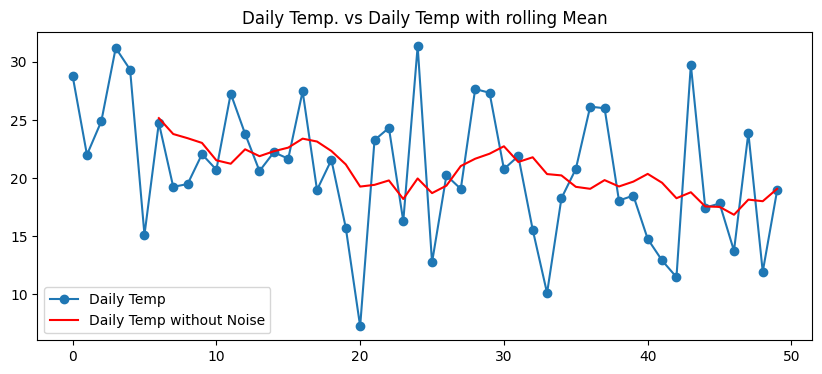

In [4]:
# series.rolling(window=)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. 50일 간의 기온을 생성
np.random.seed(0)
df = pd.DataFrame({'temp': np.random.normal(20,5,50)})
print("\n", df.head())

# 7일치 기온 데이터을 묶어서 / 기온의 평균을 구하여 열로 추가
df['7day_avg_temp'] = df['temp'].rolling(window = 7 ).mean()
print("\n", df.head(20))

# 2. 시각화
# 선 그래프 시각화
plt.figure(figsize= (10,4))
plt.plot(df['temp'],label = "Daily Temp" , marker = 'o')
plt.plot(df['7day_avg_temp'], label = "Daily Temp without Noise", color = "red")
plt.title("Daily Temp. vs Daily Temp with rolling Mean")
plt.legend()
plt.show()


In [5]:
# Min-Max scaling : 데이터 전처리 작업에서 필요
import pandas as pd
import numpy as np

# 1. 기온과 강수량 데이터 준비
data = {
    'temp': [-10, 0,15, 25, 35], # -10 ~ 35
    'rainfall' : [0, 50, 100, 200, 300] # 0 ~ 300
}

df = pd.DataFrame(data)
print("\n", df)

# 2. 0~ 1사이의 범위로 변환 (최소값  -> 0, 최대값 -> 1)
def  min_max_scale(series):
  result = (series - series.min()) / (series.max() - series.min())
  return result

df['temp_scaled'] = min_max_scale(df['temp'])
df['rainfall_scaled'] = min_max_scale(df['rainfall'])

print("\n", df)




    temp  rainfall
0   -10         0
1     0        50
2    15       100
3    25       200
4    35       300

    temp  rainfall  temp_scaled  rainfall_scaled
0   -10         0     0.000000         0.000000
1     0        50     0.222222         0.166667
2    15       100     0.555556         0.333333
3    25       200     0.777778         0.666667
4    35       300     1.000000         1.000000


In [6]:
# se.map()
import pandas as pd

# 샘플 점수 성적 데이터
df = pd.DataFrame({ 'score': [45, 56, 88, 79, 95]   })

# 규칙:  60점 미만이면 "fail", 아니면 "pass" 반환
def check_score(se):
  if se < 60:
    return "fail"
  else:
    return "pass"

# map  적용
df['result'] = df['score'].map(check_score)
print(df)

   score result
0     45   fail
1     56   fail
2     88   pass
3     79   pass
4     95   pass



                  temp  day
2026-03-01  24.613843    6
2026-03-02  24.855175    0
2026-03-03  16.135811    1
2026-03-04  12.444316    2
2026-03-05  19.581426    3

                  temp  day day_eng
2026-03-01  24.613843    6     Sun
2026-03-02  24.855175    0     Mon
2026-03-03  16.135811    1    Tues
2026-03-04  12.444316    2     Wed
2026-03-05  19.581426    3   Thurs

 day_eng
Fri      17.373220
Mon      22.082751
Sat      21.254897
Sun      20.063493
Thurs    18.836352
Tues     14.868054
Wed      13.465193
Name: temp, dtype: float64

 day_eng
Mon      22.082751
Tues     14.868054
Wed      13.465193
Thurs    18.836352
Fri      17.373220
Sat      21.254897
Sun      20.063493
Name: temp, dtype: float64


/tmp/ipykernel_16508/178919605.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x= 'day_eng', y= 'temp', palette='Set3' ) #hue = "day"


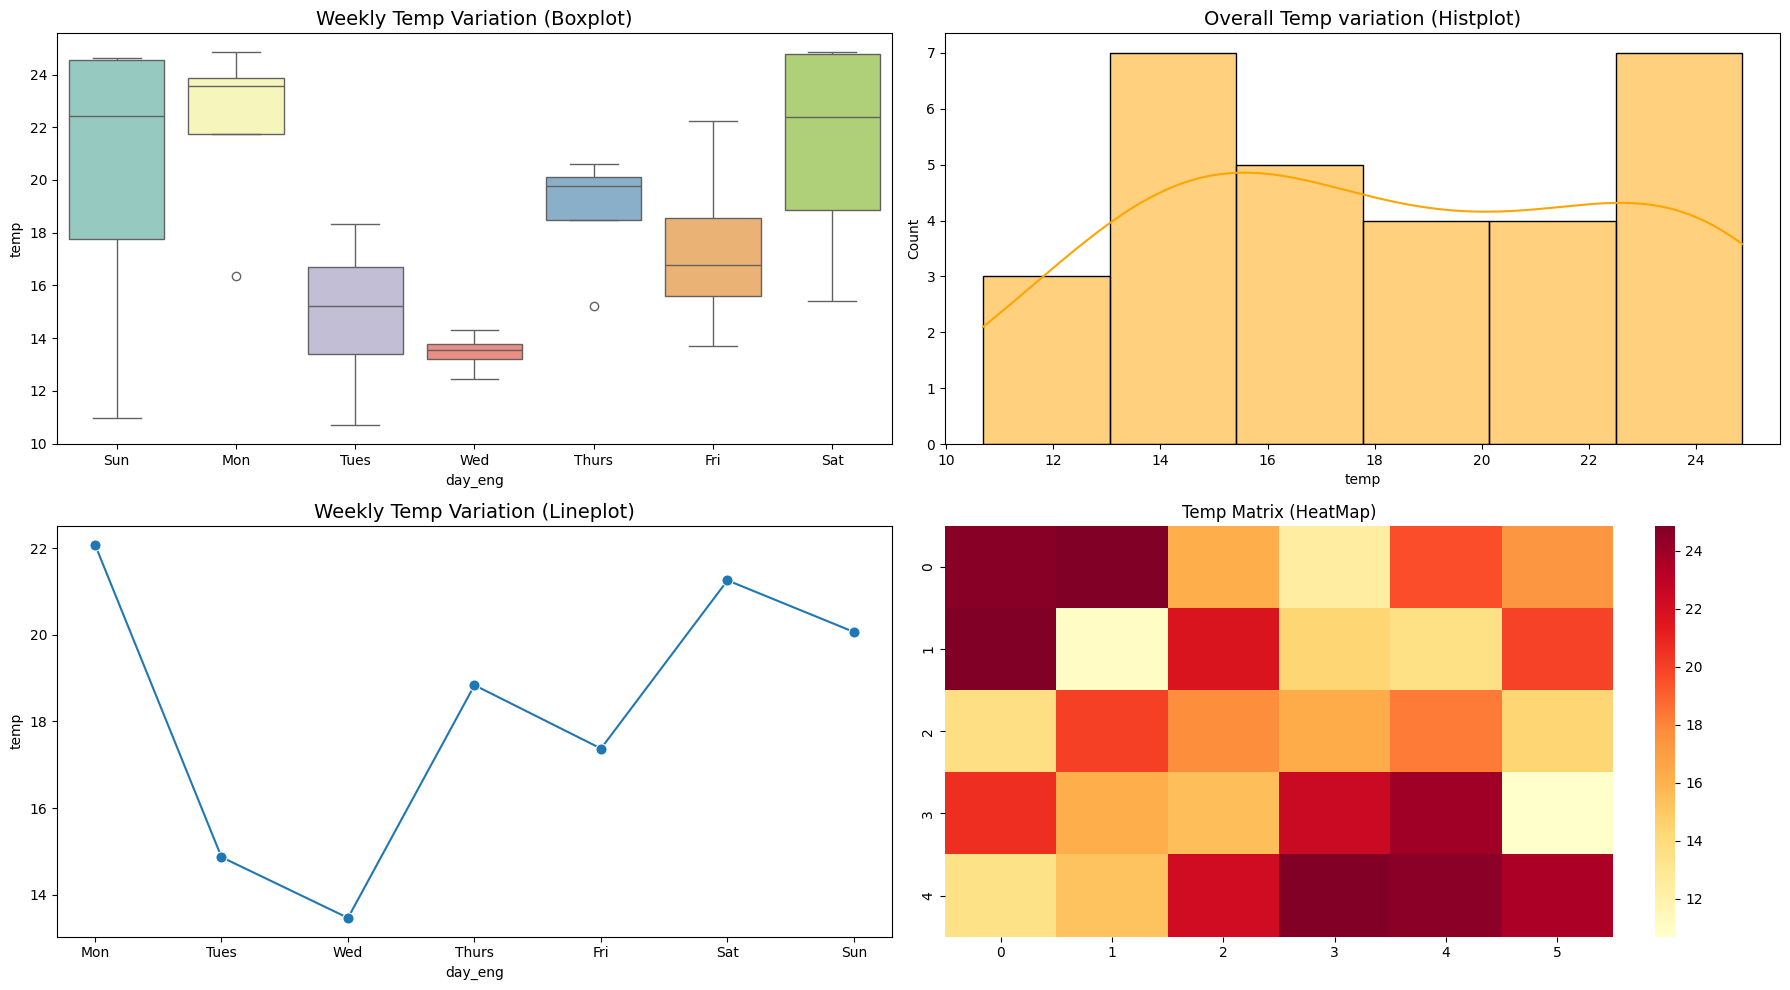

In [19]:
# pd.date_range(), df.index.dayofweek, se.reindex()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 30일치 날짜 기온 데이터
dates = pd.date_range(start="2026-03-01", periods=30) # 날짜
df = pd.DataFrame({"temp": np.random.uniform(10, 25, 30)}, index = dates) # pd.to_datetime() 는 필요없음
df['day'] = df.index.dayofweek # 요일 정보 추출
print("\n", df.head())

# 2. 숫자 요일 (0,1,2,...,6)-> 영어 요일명으로 매핑 : map() 적용
day_names = {0:'Mon', 1:'Tues', 2:'Wed', 3:'Thurs', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_eng'] = df.index.dayofweek.map(day_names)
print("\n", df.head())

# 3. 요일별 기온 평균 집계 및 재정렬 (se.reindex() 활용)
# 그룹화 후 요일 순서가 알파벳순(Fri, Mon...)으로 섞이는 것을 방지.
weekly_temp_mean = df.groupby('day_eng')['temp'].mean()
print("\n", weekly_temp_mean)
ordered_days = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
weekly_temp_mean = weekly_temp_mean.reindex(ordered_days) # 요일 순서 정렬
print("\n", weekly_temp_mean)

# 4. 종합 시각화 (plt.subplot 활용)
plt.figure(figsize=(18, 10))
# 요일별 / 기온 편차 그래프 시각화 (sns.boxplot())
plt.subplot(2, 2, 1)
sns.boxplot(data = df, x= 'day_eng', y= 'temp', palette='Set3' ) #hue = "day"
plt.title("Weekly Temp Variation (Boxplot)", fontsize=14)

# 요일별 / 기온 편차 그래프 시각화 (sns.histplot())
plt.subplot(2, 2, 2)
sns.histplot(df['temp'], kde=True, color='orange')
plt.title("Overall Temp variation (Histplot)", fontsize=14)

# 요일별 / 기온 편차 그래프 시각화 (sns.lineplot())
plt.subplot(2,2,3)
sns.lineplot(weekly_temp_mean, marker='o',  markersize = 8)
plt.title("Weekly Temp Variation (Lineplot)", fontsize=14)

# 30일치 기온 편차 그래프 시각화 (sns.heatmap())
plt.subplot(2, 2, 4)
temp_matrix = df['temp'].values.reshape(5, 6) # 가시성을 위한 5행 6열 변환
sns.heatmap(temp_matrix, cmap='YlOrRd')
plt.title("Temp Matrix (HeatMap)")
plt.tight_layout()
plt.show()
